# 📊 Chương 1: Giới Thiệu Về Time Series
## Advanced Data Science - Session 5

---

**Mục tiêu chương này:**
- Hiểu time series là gì và tại sao nó đặc biệt
- Phân biệt các loại time series
- Nắm vững cách xử lý dữ liệu time series cơ bản với Python
- Hiểu cách chia train/test đúng cách cho time series

## 1.1 Time Series Là Gì?

**Định nghĩa:** Time series (chuỗi thời gian) là một chuỗi các điểm dữ liệu được ghi nhận theo thứ tự thời gian.

### 🎯 Ví dụ minh họa dễ hiểu:

Hãy tưởng tượng bạn đo **nhiệt độ ngoài trời mỗi ngày** trong 1 năm:

| Ngày | Nhiệt độ (°C) |
|------|---------------|
| 1/1  | 18            |
| 2/1  | 17            |
| 3/1  | 19            |
| ...  | ...           |
| 31/12| 20            |

→ Đây là một **time series** vì:
- Mỗi quan sát gắn với một **thời điểm cụ thể**
- **Thứ tự thời gian** có ý nghĩa (nhiệt độ hôm nay phụ thuộc vào hôm qua)
- Không thể xáo trộn thứ tự các quan sát

### 📌 Các ví dụ thực tế:
- 📈 Giá cổ phiếu VN-Index mỗi ngày
- 🛒 Doanh số bán hàng Shopee mỗi tháng
- 🌡️ Nhiệt độ Hà Nội mỗi giờ
- 💓 Nhịp tim bệnh nhân mỗi giây
- 🚗 Lưu lượng xe trên đường mỗi 15 phút

## 1.2 Tại Sao Time Series Đặc Biệt?

### 🔑 Khác biệt quan trọng so với dữ liệu thông thường:

| Đặc điểm | Dữ liệu Thông Thường | Time Series |
|----------|---------------------|-------------|
| **Độc lập** | Các mẫu độc lập nhau | Mẫu liền kề phụ thuộc nhau |
| **Thứ tự** | Không quan trọng | **Rất quan trọng** |
| **Tương quan** | Không có tự tương quan | Có autocorrelation |
| **Train/Test** | Random split | **Sequential split** |

### 🧠 Ví dụ minh họa sự khác biệt:

**Dữ liệu thông thường (chiều cao học sinh):**
- Chiều cao của Minh (170cm) không liên quan đến chiều cao của Lan (160cm)
- Bạn có thể xáo trộn thứ tự mà không ảnh hưởng

**Time Series (giá cổ phiếu):**
- Giá hôm nay = 100k → Giá ngày mai có thể = 101k hoặc 99k (phụ thuộc hôm nay)
- Nếu xáo trộn thứ tự → mất hết ý nghĩa!

### ⚠️ Sai lầm thường gặp:
```python
# ❌ SAI: Random split cho time series
from sklearn.model_selection import train_test_split
X_train, X_test = train_test_split(data, test_size=0.2, random_state=42)

# ✅ ĐÚNG: Sequential split
train = data[:'2023-06-30']
test = data['2023-07-01':]
```

---
## 🔬 Phần Thực Hành: Làm Quen Với Time Series Trong Python
---

In [1]:
# Import các thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 12

print('✅ Import thành công!')

✅ Import thành công!


### 📝 Ví dụ 1: Tạo Time Series đơn giản từ đầu

Chúng ta sẽ tạo một chuỗi thời gian giả lập để hiểu cấu trúc cơ bản.

In [2]:
# Tạo time series giả lập: Doanh số bán hàng trong 1 năm
np.random.seed(42)

# Tạo index thời gian
dates = pd.date_range(start='2024-01-01', periods=365, freq='D')

# Tạo dữ liệu có trend + seasonality + noise
trend = np.linspace(100, 200, 365)                          # Xu hướng tăng dần
#giải thích : - `np.linspace(100, 200, 365)`: Tạo một mảng gồm 365 giá trị, bắt đầu từ 100 và kết thúc ở 200. Điều này tạo ra một xu hướng tăng dần trong doanh số bán hàng theo thời gian.

seasonality = 30 * np.sin(2 * np.pi * np.arange(365) / 365) # Mùa vụ theo năm
#Giải thích - `30 * np.sin(2 * np.pi * np.arange(365) / 365)`: Tạo một thành phần mùa vụ bằng cách sử dụng hàm sin. Điều này tạo ra một mẫu lặp lại hàng năm với biên độ 30, mô phỏng sự biến động theo mùa trong doanh số bán hàng.
noise = np.random.normal(0, 10, 365)                         # Nhiễu ngẫu nhiên

sales = trend + seasonality + noise

# Tạo DataFrame
df = pd.DataFrame({'date': dates, 'sales': sales})
df.set_index('date', inplace=True)

print(f'Shape: {df.shape}')
print(f'\nIndex type: {type(df.index)}')
print(f'Frequency: {df.index.freq}')
print(f'\n5 dòng đầu tiên:')
df.head()

Shape: (365, 1)

Index type: <class 'pandas.DatetimeIndex'>
Frequency: None

5 dòng đầu tiên:


,sales
date,
2024-01-01,104.967142
2024-01-02,99.408483
2024-01-03,108.058984
2024-01-04,117.603064
2024-01-05,100.821440


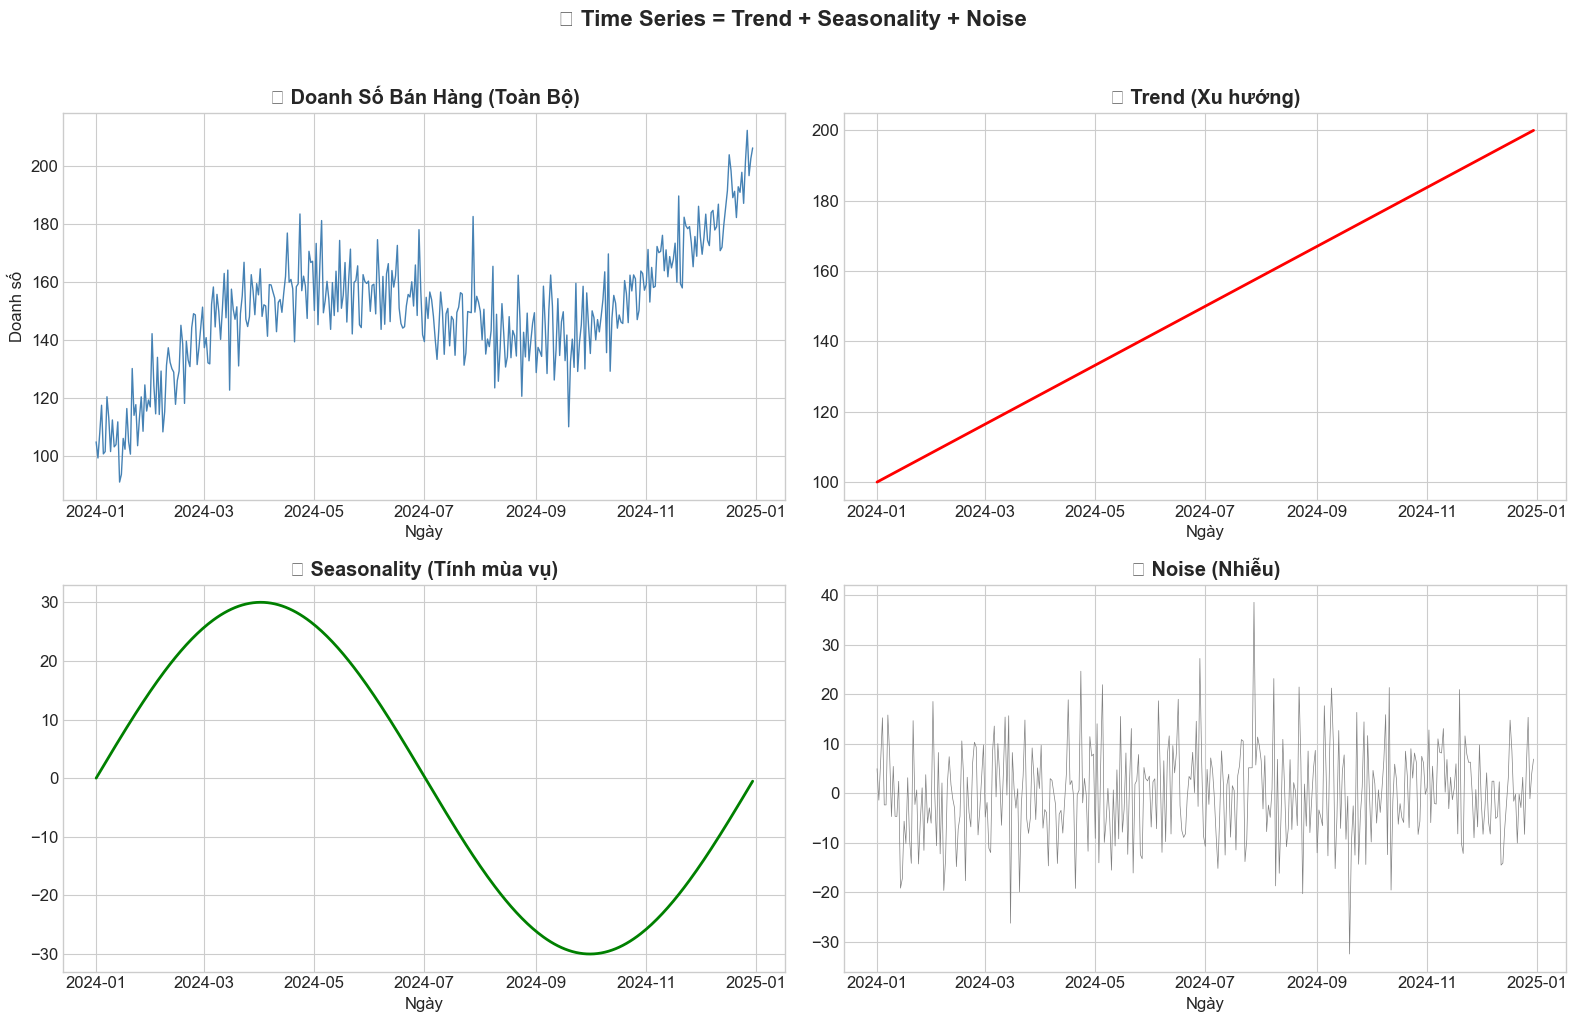


💡 Nhận xét: Time series thực tế là SỰ KẾT HỢP của nhiều thành phần!


In [3]:
# Visualize time series
fig, axes = plt.subplots(2, 2, figsize=(16, 10))


# Plot 1: Toàn bộ time series
axes[0, 0].plot(df.index, df['sales'], color='steelblue', linewidth=1)
axes[0, 0].set_title('📈 Doanh Số Bán Hàng (Toàn Bộ)', fontweight='bold')
axes[0, 0].set_xlabel('Ngày')
axes[0, 0].set_ylabel('Doanh số')

# Plot 2: Chỉ trend
axes[0, 1].plot(dates, trend, color='red', linewidth=2)
axes[0, 1].set_title('📊 Trend (Xu hướng)', fontweight='bold')
axes[0, 1].set_xlabel('Ngày')

# Plot 3: Chỉ seasonality
axes[1, 0].plot(dates, seasonality, color='green', linewidth=2)
axes[1, 0].set_title('🔄 Seasonality (Tính mùa vụ)', fontweight='bold')
axes[1, 0].set_xlabel('Ngày')

# Plot 4: Chỉ noise
axes[1, 1].plot(dates, noise, color='gray', linewidth=0.5)
axes[1, 1].set_title('📡 Noise (Nhiễu)', fontweight='bold')
axes[1, 1].set_xlabel('Ngày')

plt.suptitle('🧩 Time Series = Trend + Seasonality + Noise', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('\n💡 Nhận xét: Time series thực tế là SỰ KẾT HỢP của nhiều thành phần!')

### 📝 Ví dụ 2: Các loại Time Series

In [4]:
# Phân biệt Univariate vs Multivariate Time Series

# --- Univariate: Chỉ 1 biến theo thời gian ---
print('=== UNIVARIATE TIME SERIES ===')
print('Chỉ có 1 biến (ví dụ: chỉ doanh số)\n')

univariate = df[['sales']]
print(univariate.head())

print('\n' + '='*50)

# --- Multivariate: Nhiều biến theo thời gian ---
print('\n=== MULTIVARIATE TIME SERIES ===')
print('Nhiều biến cùng lúc (doanh số + nhiệt độ + quảng cáo)\n')

multivariate = df.copy()
multivariate['temperature'] = 25 + 10 * np.sin(2 * np.pi * np.arange(365) / 365) + np.random.normal(0, 2, 365)
multivariate['ad_spend'] = np.random.uniform(500, 2000, 365)
print(multivariate.head())

print('\n💡 Univariate: Dự đoán sales chỉ từ lịch sử sales')
print('💡 Multivariate: Dự đoán sales từ sales + nhiệt độ + chi tiêu quảng cáo')

=== UNIVARIATE TIME SERIES ===
Chỉ có 1 biến (ví dụ: chỉ doanh số)

                 sales
date                  
2024-01-01  104.967142
2024-01-02   99.408483
2024-01-03  108.058984
2024-01-04  117.603064
2024-01-05  100.821440


=== MULTIVARIATE TIME SERIES ===
Nhiều biến cùng lúc (doanh số + nhiệt độ + quảng cáo)

                 sales  temperature     ad_spend
date                                            
2024-01-01  104.967142    24.197559   527.586015
2024-01-02   99.408483    25.620319  1871.448210
2024-01-03  108.058984    25.369401   676.626624
2024-01-04  117.603064    25.711549  1364.774713
2024-01-05  100.821440    24.142005   911.082831

💡 Univariate: Dự đoán sales chỉ từ lịch sử sales
💡 Multivariate: Dự đoán sales từ sales + nhiệt độ + chi tiêu quảng cáo


### 📝 Ví dụ 3: Tần suất (Frequency) trong Time Series

Tần suất cho biết khoảng cách giữa các quan sát. Đây là khái niệm rất quan trọng.

In [5]:
# Các loại tần suất phổ biến
print('=== CÁC LOẠI TẦN SUẤT TRONG PANDAS ===')
print()

frequencies = {
    'Giây (S)': pd.date_range('2024-01-01', periods=5, freq='s'),
    'Phút (min)': pd.date_range('2024-01-01', periods=5, freq='min'),
    'Giờ (h)': pd.date_range('2024-01-01', periods=5, freq='h'),
    'Ngày (D)': pd.date_range('2024-01-01', periods=5, freq='D'),
    'Tuần (W)': pd.date_range('2024-01-01', periods=5, freq='W'),
    'Tháng (MS)': pd.date_range('2024-01-01', periods=5, freq='MS'),
    'Quý (QS)': pd.date_range('2024-01-01', periods=5, freq='QS'),
    'Năm (YS)': pd.date_range('2024-01-01', periods=5, freq='YS'),
}

for name, dates in frequencies.items():
    print(f'📅 {name}:')
    for d in dates:
        print(f'   {d}')
    print()

=== CÁC LOẠI TẦN SUẤT TRONG PANDAS ===

📅 Giây (S):
   2024-01-01 00:00:00
   2024-01-01 00:00:01
   2024-01-01 00:00:02
   2024-01-01 00:00:03
   2024-01-01 00:00:04

📅 Phút (min):
   2024-01-01 00:00:00
   2024-01-01 00:01:00
   2024-01-01 00:02:00
   2024-01-01 00:03:00
   2024-01-01 00:04:00

📅 Giờ (h):
   2024-01-01 00:00:00
   2024-01-01 01:00:00
   2024-01-01 02:00:00
   2024-01-01 03:00:00
   2024-01-01 04:00:00

📅 Ngày (D):
   2024-01-01 00:00:00
   2024-01-02 00:00:00
   2024-01-03 00:00:00
   2024-01-04 00:00:00
   2024-01-05 00:00:00

📅 Tuần (W):
   2024-01-07 00:00:00
   2024-01-14 00:00:00
   2024-01-21 00:00:00
   2024-01-28 00:00:00
   2024-02-04 00:00:00

📅 Tháng (MS):
   2024-01-01 00:00:00
   2024-02-01 00:00:00
   2024-03-01 00:00:00
   2024-04-01 00:00:00
   2024-05-01 00:00:00

📅 Quý (QS):
   2024-01-01 00:00:00
   2024-04-01 00:00:00
   2024-07-01 00:00:00
   2024-10-01 00:00:00
   2025-01-01 00:00:00

📅 Năm (YS):
   2024-01-01 00:00:00
   2025-01-01 00:00:00
   

### 📝 Ví dụ 4: Resampling - Thay Đổi Tần Suất

Một kỹ năng quan trọng: chuyển đổi tần suất dữ liệu.
- **Downsampling:** Ngày → Tuần → Tháng (giảm tần suất)
- **Upsampling:** Tháng → Tuần → Ngày (tăng tần suất)

=== DOWNSAMPLING: Ngày → Tuần / Tháng ===

Dữ liệu theo tuần: 53 tuần
Dữ liệu theo tháng: 12 tháng


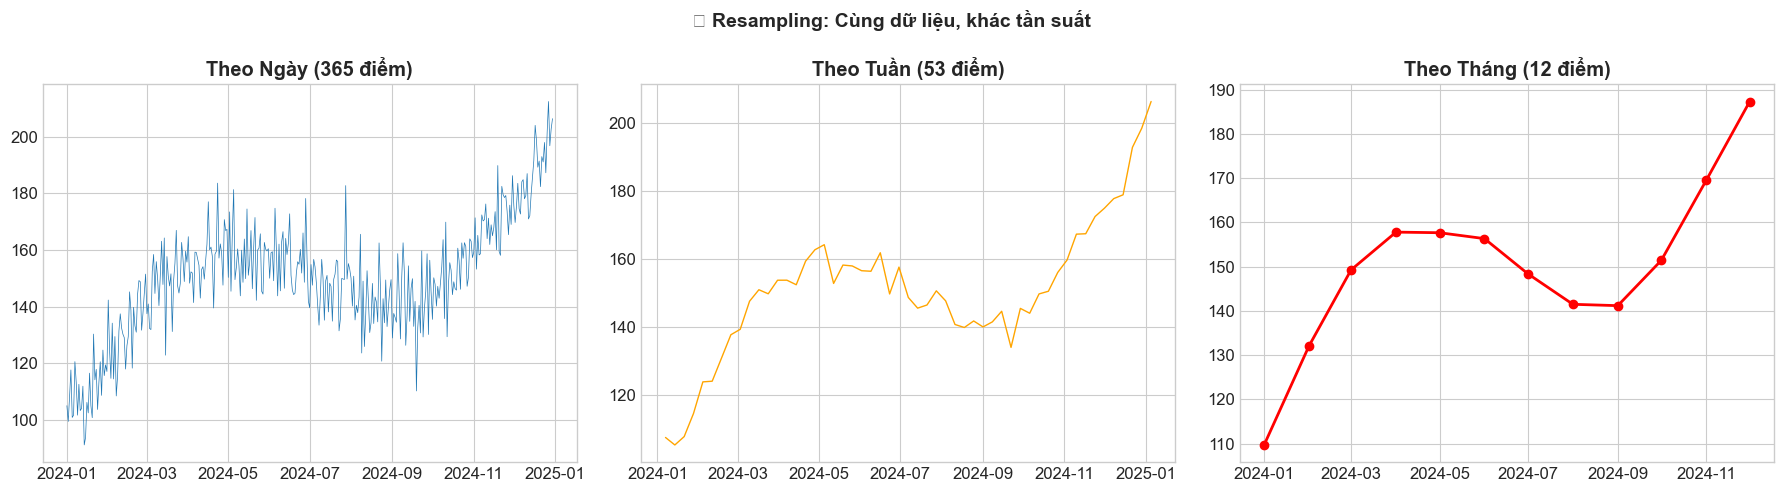


💡 Downsampling giúp giảm noise và nhìn rõ xu hướng hơn!


In [6]:
# Downsampling: Chuyển từ ngày sang tuần, tháng
print('=== DOWNSAMPLING: Ngày → Tuần / Tháng ===')

# Theo tuần (lấy trung bình)
weekly = df.resample('W').mean()
print(f'\nDữ liệu theo tuần: {weekly.shape[0]} tuần')

# Theo tháng (lấy tổng)
monthly_sum = df.resample('MS').sum()
monthly_mean = df.resample('MS').mean()
print(f'Dữ liệu theo tháng: {monthly_mean.shape[0]} tháng')

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df.index, df['sales'], linewidth=0.5)
axes[0].set_title(f'Theo Ngày ({len(df)} điểm)', fontweight='bold')

axes[1].plot(weekly.index, weekly['sales'], linewidth=1, color='orange')
axes[1].set_title(f'Theo Tuần ({len(weekly)} điểm)', fontweight='bold')

axes[2].plot(monthly_mean.index, monthly_mean['sales'], linewidth=2, color='red', marker='o')
axes[2].set_title(f'Theo Tháng ({len(monthly_mean)} điểm)', fontweight='bold')

plt.suptitle('📊 Resampling: Cùng dữ liệu, khác tần suất', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n💡 Downsampling giúp giảm noise và nhìn rõ xu hướng hơn!')

### 📝 Ví dụ 5: Train/Test Split Đúng Cách

⚠️ **Đây là điểm QUAN TRỌNG NHẤT** khi làm việc với time series!

Tổng dữ liệu: 365 ngày
Train: 292 ngày (80%) | 2024-01-01 → 2024-10-18
Test:  73 ngày (20%) | 2024-10-19 → 2024-12-30


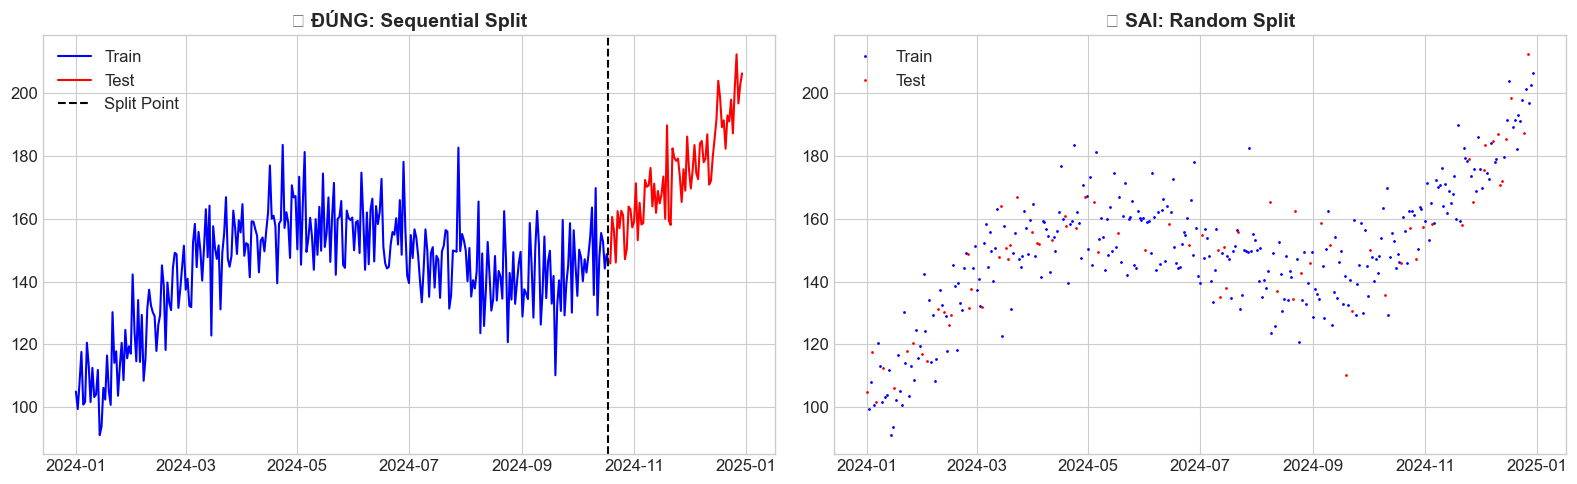


⚠️ Random Split gây DATA LEAKAGE: Test data bị "xen kẽ" với train data!
   → Model nhìn thấy "tương lai" khi train → Kết quả không đáng tin!


In [7]:
# Cách chia Train/Test ĐÚNG cho Time Series

# Tạo dữ liệu mẫu
data = df.copy()

# ✅ ĐÚNG: Chia theo thời gian (80% train, 20% test)
split_point = int(len(data) * 0.8)
train = data.iloc[:split_point]
test = data.iloc[split_point:]

print(f'Tổng dữ liệu: {len(data)} ngày')
print(f'Train: {len(train)} ngày ({len(train)/len(data)*100:.0f}%) | {train.index[0].date()} → {train.index[-1].date()}')
print(f'Test:  {len(test)} ngày ({len(test)/len(data)*100:.0f}%) | {test.index[0].date()} → {test.index[-1].date()}')

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Cách ĐÚNG
axes[0].plot(train.index, train['sales'], label='Train', color='blue')
axes[0].plot(test.index, test['sales'], label='Test', color='red')
axes[0].axvline(x=train.index[-1], color='black', linestyle='--', label='Split Point')
axes[0].set_title('✅ ĐÚNG: Sequential Split', fontweight='bold', fontsize=14)
axes[0].legend()

# Cách SAI (minh họa)
np.random.seed(42)
random_idx = np.random.choice(len(data), size=int(len(data)*0.2), replace=False)
mask = np.zeros(len(data), dtype=bool)
mask[random_idx] = True

axes[1].plot(data.index[~mask], data['sales'].values[~mask], '.', label='Train', color='blue', markersize=2)
axes[1].plot(data.index[mask], data['sales'].values[mask], '.', label='Test', color='red', markersize=2)
axes[1].set_title('❌ SAI: Random Split', fontweight='bold', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

print('\n⚠️ Random Split gây DATA LEAKAGE: Test data bị "xen kẽ" với train data!')
print('   → Model nhìn thấy "tương lai" khi train → Kết quả không đáng tin!')

### 📝 Ví dụ 6: Làm Việc Với Dữ Liệu Thực Tế

In [ ]:
# Đọc dữ liệu thực tế
data_retail = pd.read_csv('../Bai thi thu/Course Files/retail_sales_dataset.csv')

print('=== KHÁM PHÁ DỮ LIỆU ===')
print(f'Shape: {data_retail.shape}')
print(f'\nCác cột: {data_retail.columns.tolist()}')
print(f'\nKiểu dữ liệu:\n{data_retail.dtypes}')
print(f'\n5 dòng đầu:')
data_retail.head()

In [ ]:
# Xử lý cột date và thống kê mô tả
# Tìm cột ngày trong dữ liệu
print('\n=== THỐNG KÊ MÔ TẢ ===')
data_retail.describe()

---
## 🏋️ BÀI TẬP THỰC HÀNH
---

### Bài 1: Tạo Time Series từ đầu (⭐ Dễ)

Tạo một time series giả lập **nhiệt độ Hà Nội trong 2 năm** (2024-2025) với:
- Tần suất: theo ngày
- Nhiệt độ trung bình: 25°C
- Biên độ dao động mùa: 15°C (mùa hè nóng, mùa đông lạnh)
- Thêm noise ngẫu nhiên
- Visualize kết quả

Text(0.5, 0.98, 'Biểu đồ Nhiệt độ theo ngày')

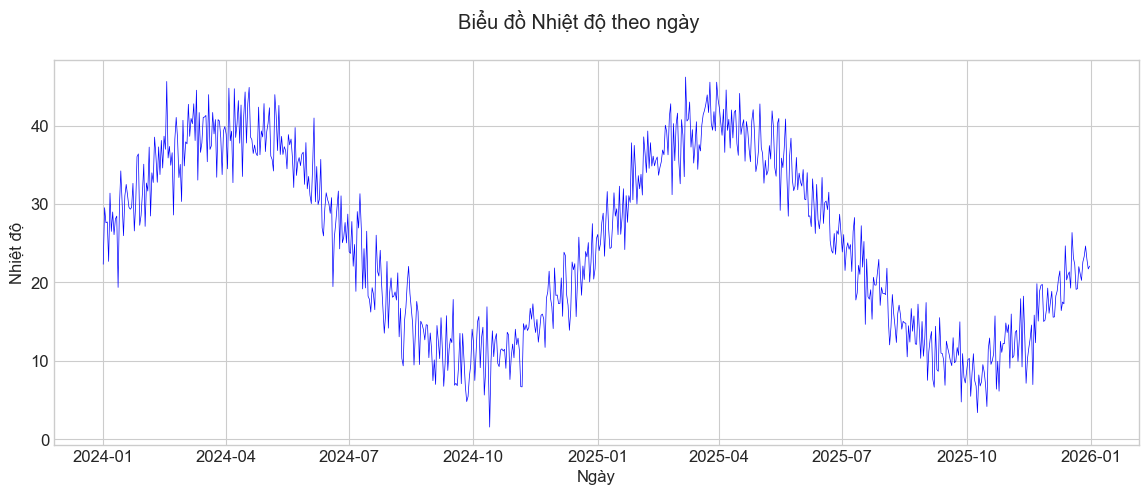

In [12]:
# TODO: Viết code ở đây
# Gợi ý:
# 1. Tạo date_range 2 năm
dates = pd.date_range(start = '2024-01-01', end = '2025-12-31', freq ='D')
# 2. temp = 25 + 15 * sin(...) + noise
temp = 25 + 15 * np.sin( 2 * np.pi * np.arange(len(dates)) / 365 ) + np.random.normal(0, 3 , len(dates))
# 3. Tạo DataFrame và set index
df_temp = pd.DataFrame({
     'dates': dates , 
     'temperature': temp
})
df_temp = df_temp.set_index('dates')
# 4. Plot biểu đồ

plt.plot(df_temp.index , df_temp['temperature'] ,linewidth = 0.5 , color = 'blue')
plt.xlabel('Ngày')
plt.ylabel('Nhiệt độ')

plt.suptitle('Biểu đồ Nhiệt độ theo ngày')

### Bài 2: Resampling (⭐⭐ Trung bình)

Sử dụng dữ liệu nhiệt độ vừa tạo ở Bài 1:
1. Resample theo **tuần** (lấy trung bình)
2. Resample theo **tháng** (lấy min, max, mean)
3. Tìm **tháng nóng nhất** và **tháng lạnh nhất**
4. Vẽ biểu đồ so sánh dữ liệu ngày vs tháng

 Tháng nóng nhất là March 2025 với nhiệt độ cao nhất là 46.19°C
 Tháng lạnh nhất là October 2024 với nhiệt độ thấp nhất là 1.55°C


Text(0.5, 0.98, 'Biểu đồ nhiệt độ theo ngày và theo tháng')

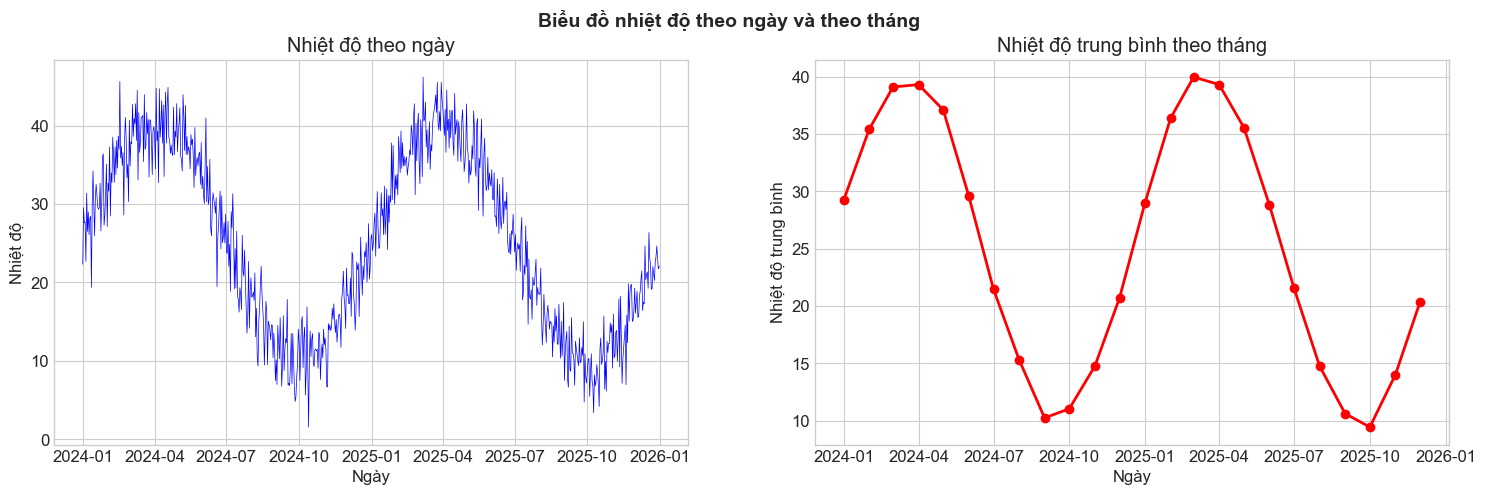

In [15]:
# TODO: Viết code ở đây

weekly = df_temp.resample('W').mean()
monthly_temp_min = df_temp.resample('MS').min()
monthly_temp_max = df_temp.resample('MS').max()
monthly_temp_mean = df_temp.resample('MS').mean()

print(f" Tháng nóng nhất là {monthly_temp_max['temperature'].idxmax().strftime('%B %Y')} với nhiệt độ cao nhất là {monthly_temp_max['temperature'].max():.2f}°C")
print(f" Tháng lạnh nhất là {monthly_temp_min['temperature'].idxmin().strftime('%B %Y')} với nhiệt độ thấp nhất là {monthly_temp_min['temperature'].min():.2f}°C")

fig , axes = plt.subplots(1,2, figsize=(18,5))
axes[0].plot(df_temp.index , df_temp['temperature'] , linewidth = 0.5 , color = 'blue')
axes[0].set_xlabel('Ngày')
axes[0].set_ylabel('Nhiệt độ')
axes[0].set_title('Nhiệt độ theo ngày')

axes[1].plot(monthly_temp_mean.index , monthly_temp_mean['temperature'], linewidth = 2 , color = 'red', marker = 'o')
axes[1].set_xlabel('Ngày')
axes[1].set_ylabel('Nhiệt độ trung bình')
axes[1].set_title('Nhiệt độ trung bình theo tháng')

plt.suptitle('Biểu đồ nhiệt độ theo ngày và theo tháng', fontsize = 14 , fontweight = 'bold')

### Bài 3: Train/Test Split (⭐⭐ Trung bình)

Với dữ liệu `retail_sales_dataset.csv`:
1. Chuyển cột ngày thành DatetimeIndex
2. Chia train/test theo tỷ lệ 70/30 (sequential split)
3. In ra phạm vi thời gian của train và test
4. Vẽ biểu đồ phân biệt train (xanh) và test (đỏ)

 Train : 584 ngày 80 bắt đầu từ ngày 2024-01-01 -> 2025-08-06 
 Test : 147 ngày 20 bắt đầu từ ngày 2025-08-07 -> 2025-12-31


Text(0.5, 1.0, 'Train vs Test set sequential split')

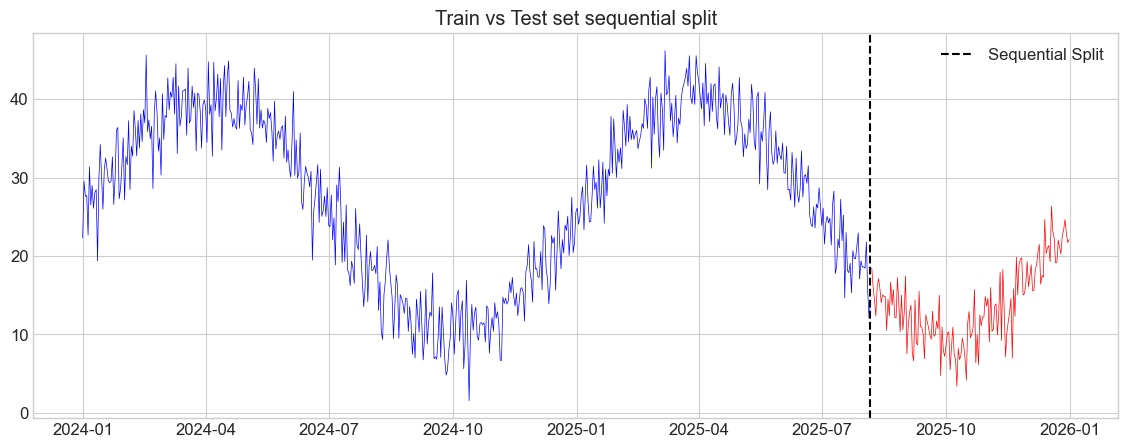

In [22]:
# TODO: Viết code ở đây

split_point = int(len(df_temp) * 0.8 ) 
train_temp = df_temp.iloc[:split_point]
test_temp = df_temp.iloc[split_point:]

print(f" Train : {int(len(train_temp))} ngày {len(train_temp) / len(df_temp) * 100:.0f} bắt đầu từ ngày {train_temp.index[0].date()} -> {train_temp.index[-1].date()} ")
print(f" Test : {int(len(test_temp))} ngày {len(test_temp) / len(df_temp) * 100:.0f} bắt đầu từ ngày {test_temp.index[0].date()} -> {test_temp.index[-1].date() }"  )

plt.plot(train_temp.index , train_temp['temperature'], color = 'blue', linewidth = 0.5)
plt.plot(test_temp.index , test_temp['temperature'], color = 'red', linewidth = 0.5) 
plt.axvline( x = train_temp.index[-1], color = 'black' , linestyle = '--' , label = 'Sequential Split')
plt.legend()
plt.title("Train vs Test set sequential split")

### Bài 4: Khám Phá Dữ Liệu Time Series (⭐⭐⭐ Nâng cao)

Đọc file `stores_sales_forecasting.csv` và thực hiện:
1. Khám phá cấu trúc dữ liệu (shape, dtypes, head, null)
2. Chuyển đổi cột ngày và set index
3. Tính thống kê theo tháng, quý
4. Xác định: dữ liệu này là univariate hay multivariate?
5. Vẽ biểu đồ time series và nhận xét về trend, seasonality

(2121, 21)
(838, 21)
 Đã drop tổng cộng 1283 dòng bị thiếu ngày tháng
<class 'pandas.DataFrame'>
DatetimeIndex: 838 entries, 2016-08-11 to 2015-06-09
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         838 non-null    int64  
 1   Order ID       838 non-null    str    
 2   Ship Date      838 non-null    str    
 3   Ship Mode      838 non-null    str    
 4   Customer ID    838 non-null    str    
 5   Customer Name  838 non-null    str    
 6   Segment        838 non-null    str    
 7   Country        838 non-null    str    
 8   City           838 non-null    str    
 9   State          838 non-null    str    
 10  Postal Code    838 non-null    int64  
 11  Region         838 non-null    str    
 12  Product ID     838 non-null    str    
 13  Category       838 non-null    str    
 14  Sub-Category   838 non-null    str    
 15  Product Name   838 non-null    str    
 16  Sales          838 n

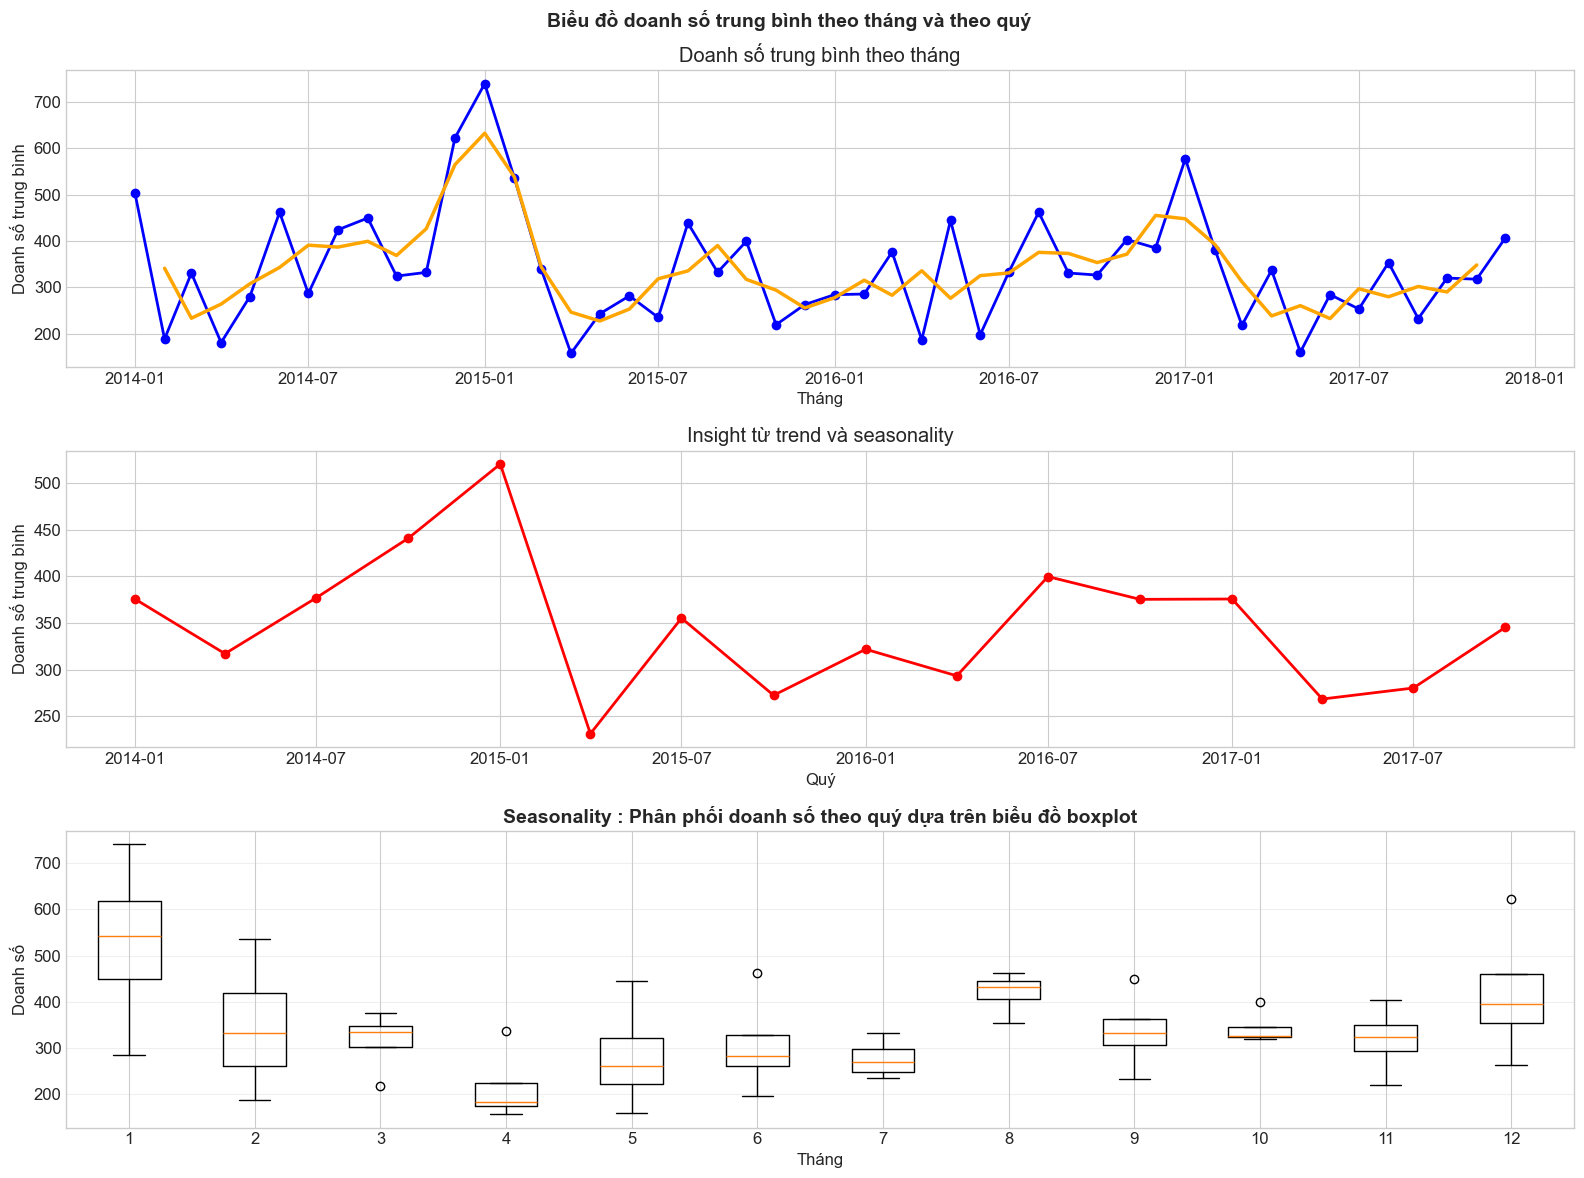

In [ ]:
# TODO: Viết code ở đây

df_store_sale = pd.read_csv('../Bai thi thu/Course Files/stores_sales_forecasting.csv', encoding= 'latin-1')

df_store_sale['Order Date'] = pd.to_datetime(df_store_sale['Order Date'], dayfirst = True , errors = 'coerce')
print(df_store_sale.shape)
df_store_sale_copy = df_store_sale.dropna(subset = 'Order Date')
print(df_store_sale_copy.shape)
print(f" Đã drop tổng cộng {df_store_sale.shape[0] - df_store_sale_copy.shape[0]} dòng bị thiếu ngày tháng" )

df_store_sale_copy = df_store_sale_copy.set_index('Order Date')
df_store_sale_copy.sort_index()

df_store_sale_copy.info()
# Resample về tháng và quý để tính thống kê 

numeric_cols = df_store_sale_copy.select_dtypes(include = [np.number]).columns
Monthly_store_sale = df_store_sale_copy[numeric_cols].resample('MS').mean()
Quarterly_store_sale = df_store_sale_copy[numeric_cols].resample('QS').mean()
print(f" Danh số trung bình theo tháng {Monthly_store_sale.head()}")
print(f" \n Danh số trung bình theo quý {Quarterly_store_sale.head()}")
print(f" vì số lượng numeric columns > 1 ========> Dữ liệu này là multivariate" )

#Moving average của 3 tháng và 6 tháng 
Moving_avg_3 = Monthly_store_sale['Sales'].rolling(window = 3 , center = True).mean()
Moving_avg_6 = Monthly_store_sale['Sales'].rolling(window = 6 ,center = True ).mean()


fig, axes = plt.subplots(3,1, figsize =(16, 12))
#Viết biểu đồ về time series nhận xét về trend và seasonality 
axes[0].plot(Monthly_store_sale.index , Monthly_store_sale['Sales'], color = 'blue', linewidth = 2 , marker = 'o', label = 'Doanh số trung bình theo tháng')
axes[0].plot(Monthly_store_sale.index , Moving_avg_3, color = 'orange', linewidth = 2.5 , label = '3 Months moving average')
axes[0].set_xlabel('Tháng')
axes[0].set_ylabel('Doanh số trung bình')
axes[0].set_title('Doanh số trung bình theo tháng')
plt.suptitle('Biểu đồ doanh số trung bình theo tháng và theo quý ', fontsize = 14
, fontweight = 'bold')

axes[1].plot(Quarterly_store_sale.index , Quarterly_store_sale['Sales'], color = 'red', linewidth = 2 , marker = 'o', label = 'Doanh số trung bình theo quý')
axes[1].set_xlabel('Quý')
axes[1].set_ylabel('Doanh số trung bình')
axes[1].set_title('Insight từ trend và seasonality')

monthly_pattern = Monthly_store_sale.copy()
monthly_pattern['Month'] = monthly_pattern.index.month
monthly_grouped = monthly_pattern.groupby('Month')['Sales'].apply(list)

axes[2].boxplot(monthly_grouped.values , labels = monthly_grouped.index)
axes[2].set_title("Seasonality : Phân phối doanh số theo quý dựa trên biểu đồ boxplot", fontsize = 14 , fontweight = 'bold')
axes[2].set_xlabel('Tháng', fontsize = 12)
axes[2].set_ylabel('Doanh số', fontsize = 12)
axes[2].grid(True , alpha = 0.3 , axis = 'y')
plt.tight_layout()
plt.show()